# Banknote Authentication with Gradient Boosting

This notebook walks through **supervised gradient boosting classification** on the **Banknote Authentication** dataset (wavelet-transform statistics computed from banknote images). The workflow mirrors the structure used in the k-nearest neighbors notebook: a clear path from raw data to model, plots, and a written discussion of results.

The first code cell imports libraries and sets plot defaults. **Notebook outline:**

1. Load data and basic quality checks  
2. Exploratory analysis (class balance and feature behavior)  
3. Train / test split and feature standardization  
4. Fit a gradient boosting classifier from `rice_ml`  
5. Test-set evaluation and confusion matrix  
6. Visualizations  
7. Feature importance  
8. Discussion and limitations

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from rice_ml.processing.datasets import find_data_file
from rice_ml.processing.pre_processing import StandardScaler, train_test_split
from rice_ml.processing.post_processing import (
    accuracy_score,
    confusion_matrix,
    precision_recall_f1,
    roc_auc_score,
)
from rice_ml.supervised_learning.gradient_boosting import GradientBoostingClassifier

warnings.filterwarnings("ignore")
np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

## 1. Load data and quality checks

We read `BankNote_Authentication.csv` via `find_data_file` so the notebook runs from the repo root, from this folder, or from Jupyter with any working directory.

In [2]:
# Load data from this repository's data folder.
df = pd.read_csv(find_data_file("BankNote_Authentication.csv"))

# This dataset should already be complete, but drop missing rows defensively.
df = df.dropna().copy()

feature_names = ["variance", "skewness", "curtosis", "entropy"]
target = "class"

print("Shape:", df.shape)
print("Class counts:")
print(df[target].value_counts().sort_index())

df.head()

Shape: (1372, 5)
Class counts:
class
0    762
1    610
Name: count, dtype: int64


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 2. Exploratory analysis

Gradient boosting builds an additive sequence of shallow trees. The plots below check whether the two classes are balanced, whether feature ranges contain outliers, and whether simple two-feature views already show separation.

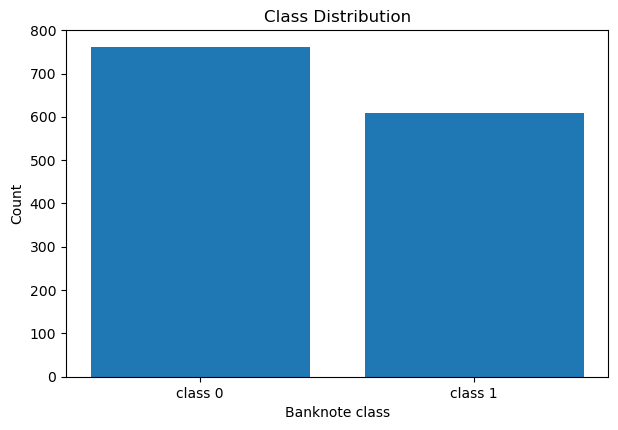

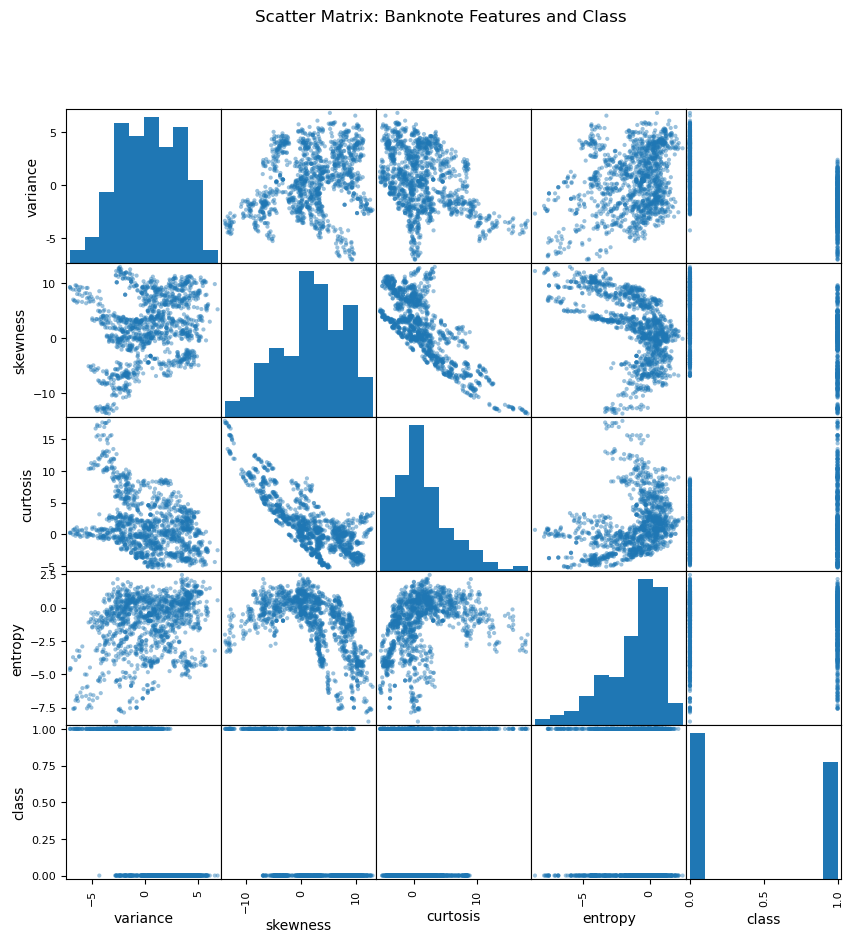

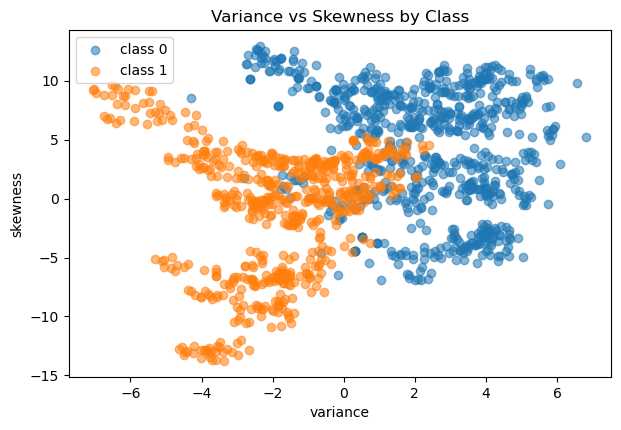

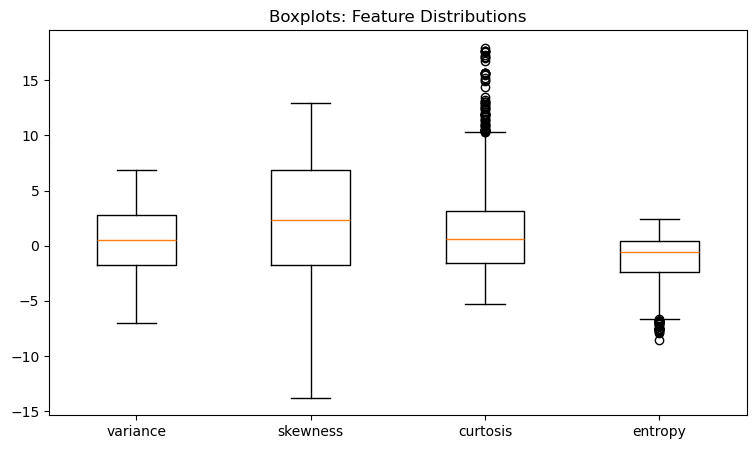

In [3]:
# Target distribution.
plt.figure()
plt.bar(["class 0", "class 1"], df[target].value_counts().sort_index().values)
plt.xlabel("Banknote class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

# Scatter matrix of the numeric features and target.
scatter_matrix(df[feature_names + [target]], figsize=(10, 10), diagonal="hist", alpha=0.45)
plt.suptitle("Scatter Matrix: Banknote Features and Class")
plt.show()

# Interaction: two useful features colored by class.
for cls, label, color in [(0, "class 0", "tab:blue"), (1, "class 1", "tab:orange")]:
    mask = df[target] == cls
    plt.scatter(df.loc[mask, "variance"], df.loc[mask, "skewness"], label=label, alpha=0.55, color=color)
plt.xlabel("variance")
plt.ylabel("skewness")
plt.title("Variance vs Skewness by Class")
plt.legend()
plt.show()

# Boxplots for feature distributions.
plt.figure(figsize=(9, 5))
plt.boxplot([df[f] for f in feature_names], labels=feature_names)
plt.title("Boxplots: Feature Distributions")
plt.show()

## 3. Train / test split and scaling

We stratify on `class` so both banknote classes appear in both splits. `StandardScaler` is fit **only on the training fold** and applied to the test set to mimic honest deployment practice.

In [4]:
X = df[feature_names].to_numpy(dtype=float)
y = df[target].to_numpy(dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

## 4. Fit a gradient boosting classifier

The model below uses the project implementation in `src/rice_ml/supervised_learning/gradient_boosting.py`. Each shallow regression tree is fit to the current pseudo-residuals, and the ensemble updates the log-odds score stage by stage.

In [5]:
model = GradientBoostingClassifier(
    n_estimators=60,
    learning_rate=0.12,
    max_depth=2,
    random_state=0,
)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_score = model.predict_proba(X_test_s)[:, 1]

## 5. Test-set evaluation

We report hold-out accuracy, ROC-AUC, precision, recall, and F1. The confusion matrix uses rows for true labels and columns for predicted labels.

Test Accuracy: 0.9503
Test ROC-AUC:  0.9857
Precision:     0.9655
Recall:        0.9211
F1:            0.9428


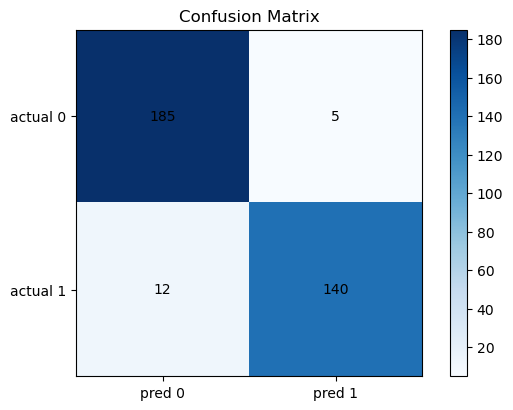

In [6]:
y_true = y_test

prf = precision_recall_f1(y_true, y_pred, positive_label=1)
acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test ROC-AUC:  {auc:.4f}")
print(f"Precision:     {prf['precision']:.4f}")
print(f"Recall:        {prf['recall']:.4f}")
print(f"F1:            {prf['f1']:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure()
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["actual 0", "actual 1"])
plt.title("Confusion Matrix")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.show()

## 6. Visualizations

The probability histogram shows whether the classifier is confident or leaves many observations near the 0.50 cutoff. The ROC curve checks the quality of the probability ranking across many thresholds.

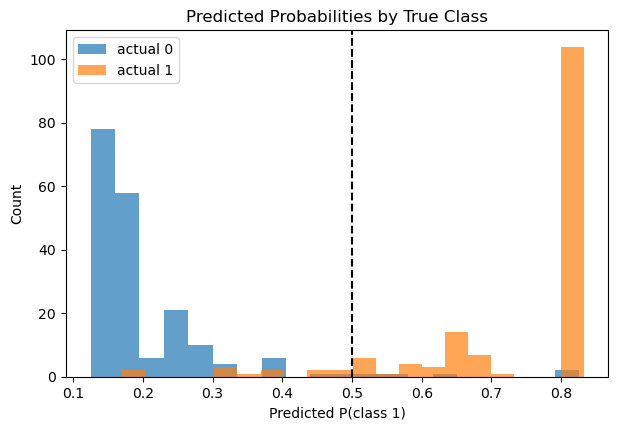

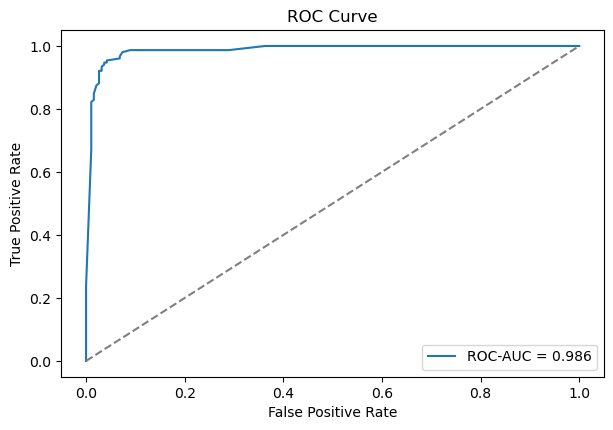

In [7]:
# Predicted probability distribution by true class.
plt.figure()
plt.hist(y_score[y_true == 0], bins=20, alpha=0.7, label="actual 0")
plt.hist(y_score[y_true == 1], bins=20, alpha=0.7, label="actual 1")
plt.axvline(0.5, linestyle="--", color="black")
plt.xlabel("Predicted P(class 1)")
plt.ylabel("Count")
plt.title("Predicted Probabilities by True Class")
plt.legend()
plt.show()

# ROC curve.
thresholds = np.linspace(0, 1, 101)
tpr = []
fpr = []
for threshold in thresholds:
    pred_t = (y_score >= threshold).astype(int)
    tn = np.sum((y_true == 0) & (pred_t == 0))
    fp = np.sum((y_true == 0) & (pred_t == 1))
    fn = np.sum((y_true == 1) & (pred_t == 0))
    tp = np.sum((y_true == 1) & (pred_t == 1))
    tpr.append(tp / (tp + fn) if (tp + fn) else 0.0)
    fpr.append(fp / (fp + tn) if (fp + tn) else 0.0)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 7. Feature importance

This `rice_ml` implementation records how often each feature is used in tree splits across the boosted ensemble. Larger values mean the feature appears more often in the learned split structure.

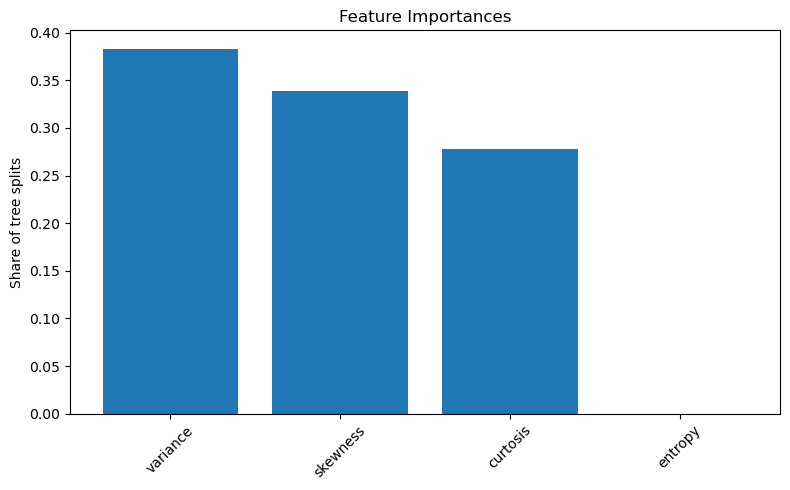

variance    0.3833
skewness    0.3389
curtosis    0.2778
entropy     0.0000
dtype: float64

In [8]:
plt.figure(figsize=(8, 5))
importances = model.feature_importances_
plt.bar(feature_names, importances)
plt.xticks(rotation=45)
plt.ylabel("Share of tree splits")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

importance_table = pd.Series(importances, index=feature_names).sort_values(ascending=False)
importance_table.round(4)

## 8. Discussion

**Model performance (test set).** The printed summary below is generated from the actual run so it stays consistent with the plots.

**Boosting behavior.** Gradient boosting combines many shallow trees, so it can capture nonlinear boundaries without relying on one deep tree. The learning rate and number of estimators control how cautiously the ensemble updates from stage to stage.

**Probability structure.** The histogram and ROC curve show whether class 0 and class 1 receive well-separated probabilities. A strong ROC-AUC means the model ranks authentic and forged examples cleanly over many possible thresholds.

**Feature importance.** Split-frequency importance is a simple internal diagnostic: it does not prove causality, but it does show which banknote statistics the boosted trees used most often.

**Limitations.** This is still a small tabular hold-out experiment. A more complete study would tune `n_estimators`, `learning_rate`, and `max_depth` with cross-validation, then compare against logistic regression, random forests, and a single decision tree.

In [ ]:
print("--- Auto-generated results summary ---")
print(f"Test accuracy: {acc:.4f}")
print(f"Test ROC-AUC: {auc:.4f}")
print(f"Precision / recall / F1: {prf['precision']:.4f} / {prf['recall']:.4f} / {prf['f1']:.4f}")
print("Feature importance ranking:")
print(importance_table.round(4))